In [1]:
import os
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Download latest version
path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")

print("Path to dataset files:", path)

In [4]:
for dirname , _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_path = os.path.join(dirname, filename)
           
        print(os.path.join(dirname, filename))
        path = os.path.join(dirname, filename)
if csv_path == None:
    for filename in os.listdir(path):
        if filename.endswith('.csv'):
         csv_path = os.path.join(path, filename)
         break

print("CSV file found:", csv_path)

CSV file found: /home/keq/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1/Synthetic_Financial_datasets_log.csv


In [5]:
df = pd.read_csv(csv_path)
df_fraud = df[df['isFraud'] == 1]
print("Jumlah transaksi fraud:", len(df_fraud))
df_fraud.head()

Jumlah transaksi fraud: 8213


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0


In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [8]:
mv = df.isna().sum()
print('\nMissing Values:\n', mv)


Missing Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [9]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [128]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [129]:
numerical= ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
categorical = ['type']

In [10]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [130]:
df['type'].unique()

<StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

In [131]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [132]:
df_fraud['type'].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

In [133]:
#convert categorical to numerical
df_pearson = df.copy()
df_pearson['type'] = df_pearson['type'].map({'PAYMENT': 0, 'TRANSFER': 1, 'CASH_OUT': 2, 'DEBIT': 3, 'CASH_IN': 4}) 
df_fraud['type'] = df_fraud['type'].map({'PAYMENT': 0, 'TRANSFER': 1, 'CASH_OUT': 2, 'DEBIT': 3, 'CASH_IN': 4})

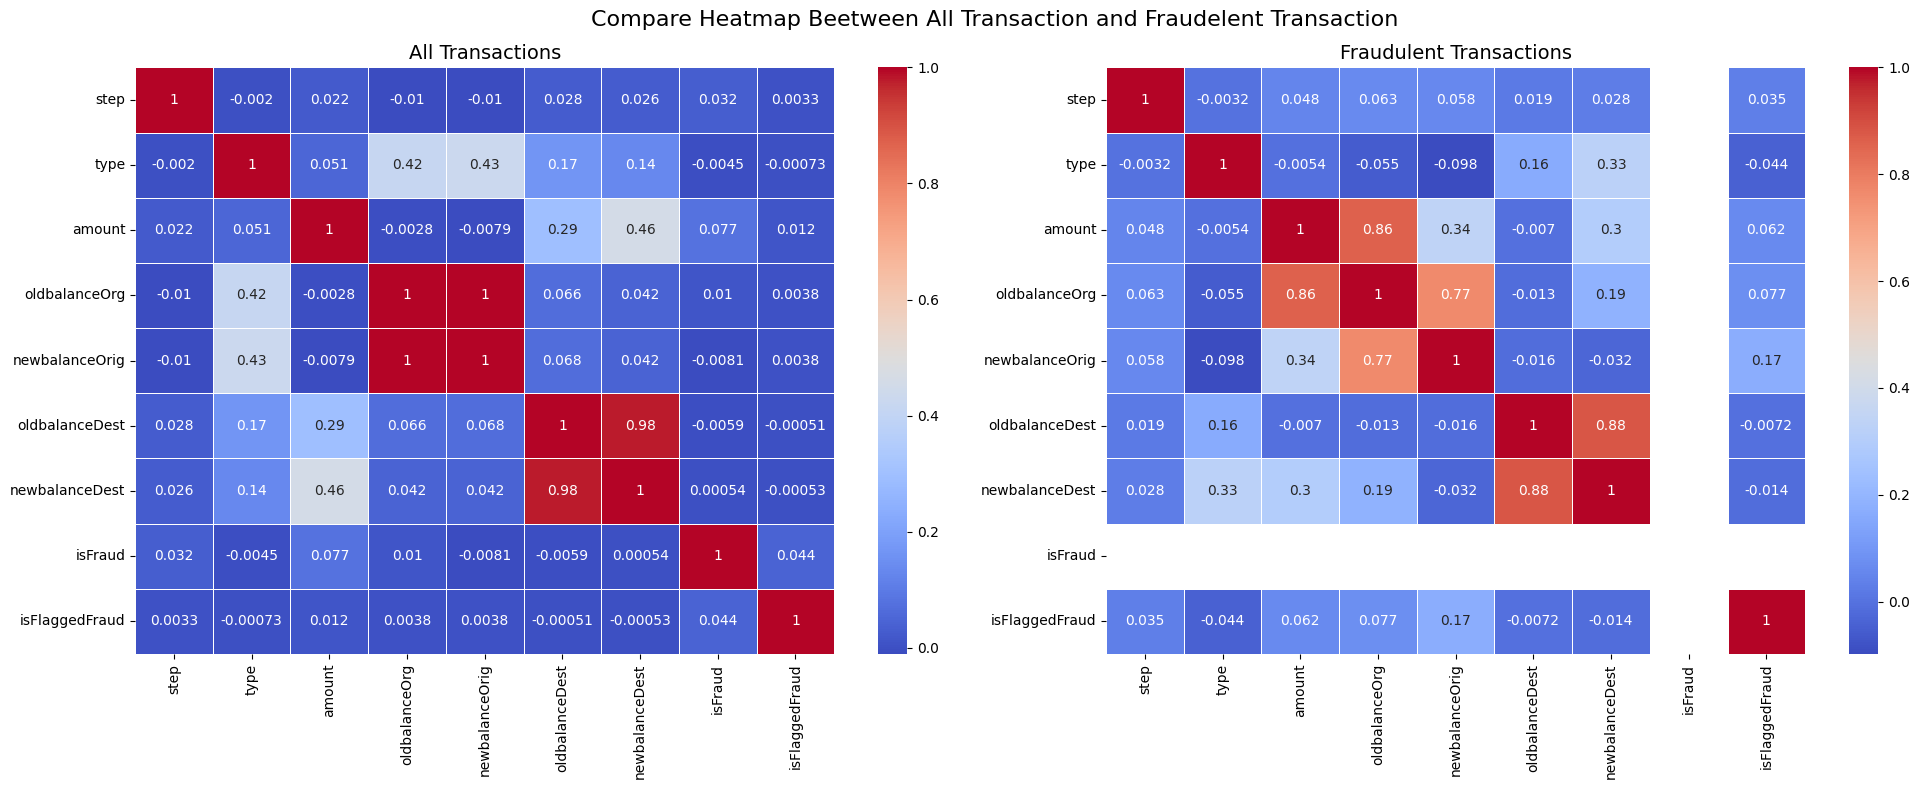

In [134]:
correlation = df_pearson.corr(method='pearson',numeric_only=True)
correlation_fraud = df_fraud.corr(method='pearson',numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Compare Heatmap Beetween All Transaction and Fraudelent Transaction', fontsize=16)

sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=ax[0],linewidths=0.5)
ax[0].set_title('All Transactions', fontsize=14)
sns.heatmap(correlation_fraud, annot=True, cmap='coolwarm', ax=ax[1],linewidths=0.5)
ax[1].set_title('Fraudulent Transactions', fontsize=14)

plt.tight_layout()
plt.show()

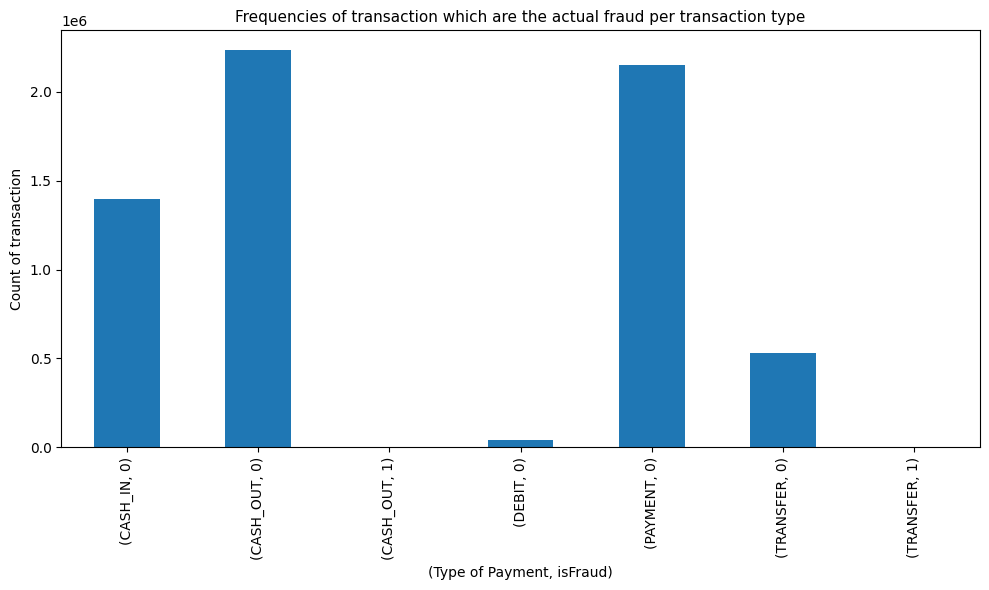

In [135]:
# 1. Groupby berdasarkan 'type' dan 'isFraud', lalu hitung jumlahnya
grouped_data = df.groupby(['type', 'isFraud']).size()

# 2. Buat plot diagram batang
plt.figure(figsize=(10, 6))
grouped_data.plot(kind='bar', color='#1f77b4') # warna biru standar matplotlib

# 3. Atur judul dan label persis seperti di gambar image_fe098b.png
plt.title('Frequencies of transaction which are the actual fraud per transaction type', fontsize=11)
plt.xlabel('(Type of Payment, isFraud)', fontsize=10)
plt.ylabel('Count of transaction', fontsize=10)

# 4. Agar teks label di sumbu X tidak terpotong saat disimpan/ditampilkan
plt.tight_layout()
plt.show()

In [136]:
df_pearson.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,0,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,0,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,2,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,0,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df_selected =pd.get_dummies(df, columns=['type'],dtype=int)
# Masukkan kembali oldbalanceOrg dan newbalanceDest!
selected_features = [
    'amount', 
    'oldbalanceOrg',   
    'newbalanceOrig', 
    'oldbalanceDest', 
    'newbalanceDest',  
    'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'
]
X = df_selected[selected_features]

y = df_selected['isFraud']
# df_selected.head()
X.head()


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,0,0,0,1,0
1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0,1,0
2,181.00,181.0,0.00,0.0,0.0,0,0,0,0,1
3,181.00,181.0,0.00,21182.0,0.0,0,1,0,0,0
4,11668.14,41554.0,29885.86,0.0,0.0,0,0,0,1,0


In [138]:
#split data 70 train 30 test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [139]:
#Resampling train data using Random Over Sampler
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)
print("Original training set class distribution:")
print(y_train.value_counts())
print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")

Original training set class distribution:
isFraud
0    4448056
1       5778
Name: count, dtype: int64

Resampled training set class distribution:
isFraud
0    4448056
1    4448056
Name: count, dtype: int64
X_test shape: (1908786, 10)
y_test shape: (1908786,)
X_train_resampled shape: (8896112, 10)
y_train_resampled shape: (8896112,)


In [140]:
# #smote implementation
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# print("Original training set class distribution:")
# print(y_train.value_counts())
# print("\nSMOTE Resampled training set class distribution:")
# print(y_train_smote.value_counts())

In [141]:
import sklearn
import joblib
import pandas
print ("Pandas:", pandas.__version__)
print("Sklearn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Pandas: 3.0.2
Sklearn: 1.6.1
Joblib: 1.5.3


In [ ]:
import joblib

# Tambahkan .values agar tersimpan sebagai NumPy Array murni
joblib.dump(X_train_resampled.values, 'X_train_resampled_values_v2.pkl')
joblib.dump(y_train_resampled.values, 'y_train_resampled_values_v2.pkl')
joblib.dump(X_test.values, 'X_test_values_v2.pkl')
joblib.dump(y_test.values, 'y_test_values_v2.pkl')

print("Selesai! Data sudah dibersihkan dari struktur Pandas dan siap di-upload ulang.")

Selesai! Data sudah dibersihkan dari struktur Pandas dan siap di-upload ulang.


In [143]:
# 1. Intip baris pertama versi Pandas DataFrame
print("=== VERSI PANDAS (Ada nama kolomnya) ===")
print(X_train_resampled.iloc[0]) 

print("\n" + "="*40 + "\n")

# 2. Konversi ke NumPy Array
X_numpy = X_train_resampled.values

# 3. Intip baris pertama versi NumPy murni
print("=== VERSI NUMPY (Hanya angka murni) ===")
print(X_numpy[0])

=== VERSI PANDAS (Ada nama kolomnya) ===
amount              26771.98
oldbalanceOrg       27521.00
newbalanceOrig      54292.98
oldbalanceDest    7175503.03
newbalanceDest    7148731.05
type_CASH_IN            1.00
type_CASH_OUT           0.00
type_DEBIT              0.00
type_PAYMENT            0.00
type_TRANSFER           0.00
Name: 0, dtype: float64


=== VERSI NUMPY (Hanya angka murni) ===
[2.67719800e+04 2.75210000e+04 5.42929800e+04 7.17550303e+06
 7.14873105e+06 1.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
